#India AQI Category Classifier

**Platform:** Google Colab (Free Tier) — RAM Optimized  
**Dataset:** 842,160 hourly records | 71 columns | Indian Cities  
**Task:** Classify `AQI_Category` → Good / Moderate / Unhealthy / Very Unhealthy / Hazardous  


## 1. Imports & Setup

In [ ]:
!pip install lightgbm xgboost scikit-learn imbalanced-learn -q
print('Libraries ready')

Libraries ready


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, gc
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import lightgbm as lgb
import joblib

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')
SEED = 42
print('All imports successful!')

All imports successful!


## 2. Load Dataset from Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

FILE_NAME = '/content/drive/MyDrive/ML 2026/INDIA_AQI_COMPLETE_20261126.csv'

# Optimized dtypes — saves ~50% RAM vs default float64/int64
DTYPES = {
    'City': 'category', 'State': 'category',
    'Latitude': 'float32', 'Longitude': 'float32',
    'Year': 'int16', 'Month': 'int8', 'Day': 'int8',
    'Hour': 'int8', 'Day_of_Week': 'int8', 'Day_Name': 'category',
    'Week_of_Year': 'int8', 'Is_Weekend': 'bool', 'Quarter': 'int8',
    'Season': 'category', 'Time_of_Day': 'category',
    'Temp_2m_C': 'float32', 'Temp_80m_C': 'float32',
    'Temp_120m_C': 'float32', 'Temp_180m_C': 'float32',
    'Humidity_Percent': 'float32', 'Dew_Point_C': 'float32',
    'Humidity_Category': 'category',
    'Wind_Speed_10m_kmh': 'float32', 'Wind_Speed_80m_kmh': 'float32',
    'Wind_Speed_120m_kmh': 'float32', 'Wind_Dir_10m': 'float32',
    'Wind_Gusts_kmh': 'float32', 'Wind_Category': 'category',
    'Wind_Stagnation': 'bool', 'Precipitation_mm': 'float32',
    'Rain_mm': 'float32', 'Is_Raining': 'bool', 'Heavy_Rain': 'bool',
    'Pressure_MSL_hPa': 'float32', 'Surface_Pressure_hPa': 'float32',
    'Solar_Radiation_Wm2': 'float32', 'Direct_Radiation_Wm2': 'float32',
    'Diffuse_Radiation_Wm2': 'float32', 'UV_Index': 'float32',
    'Cloud_Cover_Percent': 'float32', 'Cloud_Low_Percent': 'float32',
    'Cloud_Mid_Percent': 'float32', 'Cloud_High_Percent': 'float32',
    'Is_Daytime': 'bool', 'Sunshine_Seconds': 'float32',
    'PM2_5_ugm3': 'float32', 'PM10_ugm3': 'float32',
    'PM_Ratio': 'float32', 'CO_ugm3': 'float32',
    'NO2_ugm3': 'float32', 'SO2_ugm3': 'float32',
    'O3_ugm3': 'float32', 'Dust_ugm3': 'float32',
    'NH3_ugm3': 'float32', 'AOD': 'float32',
    'US_AQI': 'float32', 'US_AQI_PM25': 'float32',
    'US_AQI_PM10': 'float32', 'US_AQI_NO2': 'float32',
    'US_AQI_O3': 'float32', 'US_AQI_CO': 'float32',
    'EU_AQI': 'float32', 'EU_AQI_PM25': 'float32',
    'EU_AQI_PM10': 'float32',
    'AQI_Category': 'category', 'PM25_Category_India': 'category',
    'Temp_Inversion': 'bool', 'Inversion_Strength_C': 'float32',
    'Festival_Period': 'bool', 'Crop_Burning_Season': 'bool'
}

df = pd.read_csv(FILE_NAME, dtype=DTYPES, low_memory=False)
print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Memory usage: {df.memory_usage(deep=True).sum()/1e6:.1f} MB')
df.head(3)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Loaded: 842,160 rows x 71 columns
Memory usage: 233.3 MB


,City,State,Latitude,Longitude,Datetime,Year,Month,Day,Hour,Day_of_Week,...,US_AQI_CO,EU_AQI,EU_AQI_PM25,EU_AQI_PM10,AQI_Category,PM25_Category_India,Temp_Inversion,Inversion_Strength_C,Festival_Period,Crop_Burning_Season
0,Agartala,Tripura,23.831499,91.286797,2022-08-05 00:00:00,2022,8,5,0,4,...,2.0,NaN,NaN,NaN,NaN,Good,False,NaN,False,False
1,Agartala,Tripura,23.831499,91.286797,2022-08-05 01:00:00,2022,8,5,1,4,...,2.0,NaN,NaN,NaN,NaN,Good,False,NaN,False,False
2,Agartala,Tripura,23.831499,91.286797,2022-08-05 02:00:00,2022,8,5,2,4,...,2.0,NaN,NaN,NaN,NaN,Good,False,NaN,False,False


## 3. Exploratory Data Analysis

In [ ]:
print('Shape:', df.shape)
print('Cities:', df['City'].nunique(), '| States:', df['State'].nunique())
print('\nNull values:')
nulls = df.isnull().sum()
print(nulls[nulls > 0] if nulls.sum() > 0 else 'None')
print('\nTarget distribution:')
print(df['AQI_Category'].value_counts())

Shape: (842160, 71)
Cities: 29 | States: 29

Null values:
Temp_80m_C              842160
Temp_120m_C             842160
Temp_180m_C             842160
Wind_Speed_80m_kmh      842160
Wind_Speed_120m_kmh     842160
UV_Index                842160
NH3_ugm3                842160
US_AQI                     145
US_AQI_PM25                145
US_AQI_PM10                145
US_AQI_NO2                   2
US_AQI_O3                   73
EU_AQI                     145
EU_AQI_PM25                145
EU_AQI_PM10                145
AQI_Category              2516
PM25_Category_India          2
Inversion_Strength_C    842160
dtype: int64

Target distribution:
AQI_Category
Moderate               385769
Unhealthy_Sensitive    175071
Good                   136459
Unhealthy              130352
Very_Unhealthy          10354
Hazardous                1639
Name: count, dtype: int64


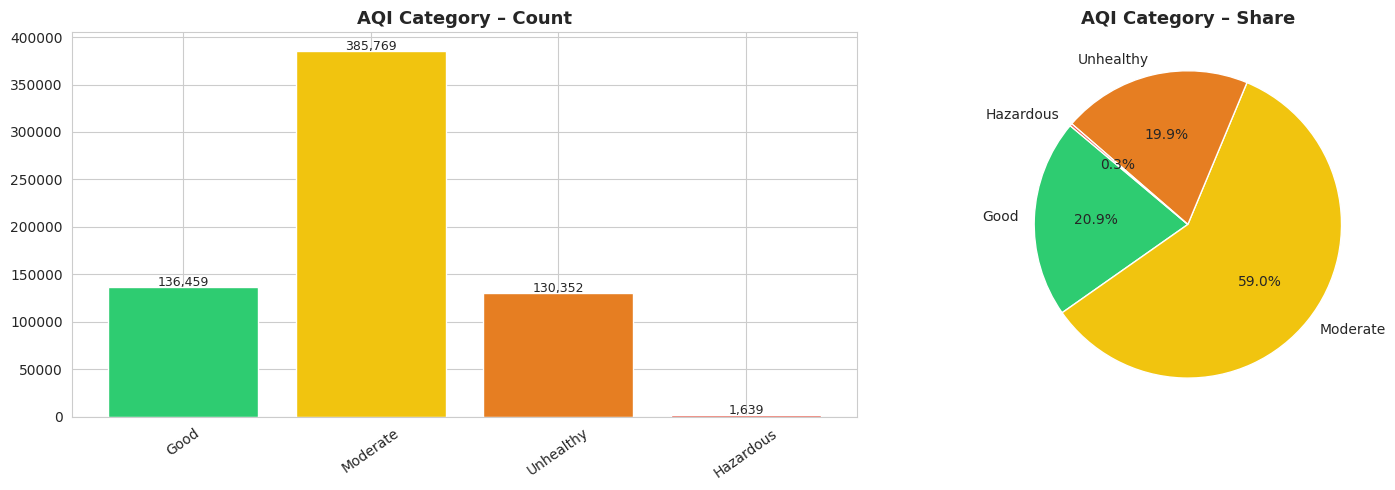

In [ ]:
# AQI Category distribution
AQI_ORDER  = ['Good','Moderate','Unhealthy for Sensitive Groups',
               'Unhealthy','Very Unhealthy','Hazardous']
AQI_COLORS = ['#2ecc71','#f1c40f','#e67e22','#e74c3c','#8e44ad','#2c3e50']
present    = [c for c in AQI_ORDER if c in df['AQI_Category'].cat.categories]
cat_counts = df['AQI_Category'].value_counts().reindex(present)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
bars = axes[0].bar(cat_counts.index, cat_counts.values,
                    color=AQI_COLORS[:len(present)], edgecolor='white')
axes[0].set_title('AQI Category – Count', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', rotation=35)
for bar in bars:
    axes[0].text(bar.get_x()+bar.get_width()/2,
                  bar.get_height()+1000,
                  f'{int(bar.get_height()):,}', ha='center', fontsize=9)
axes[1].pie(cat_counts.values, labels=cat_counts.index,
             autopct='%1.1f%%', startangle=140,
             colors=AQI_COLORS[:len(present)])
axes[1].set_title('AQI Category – Share', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

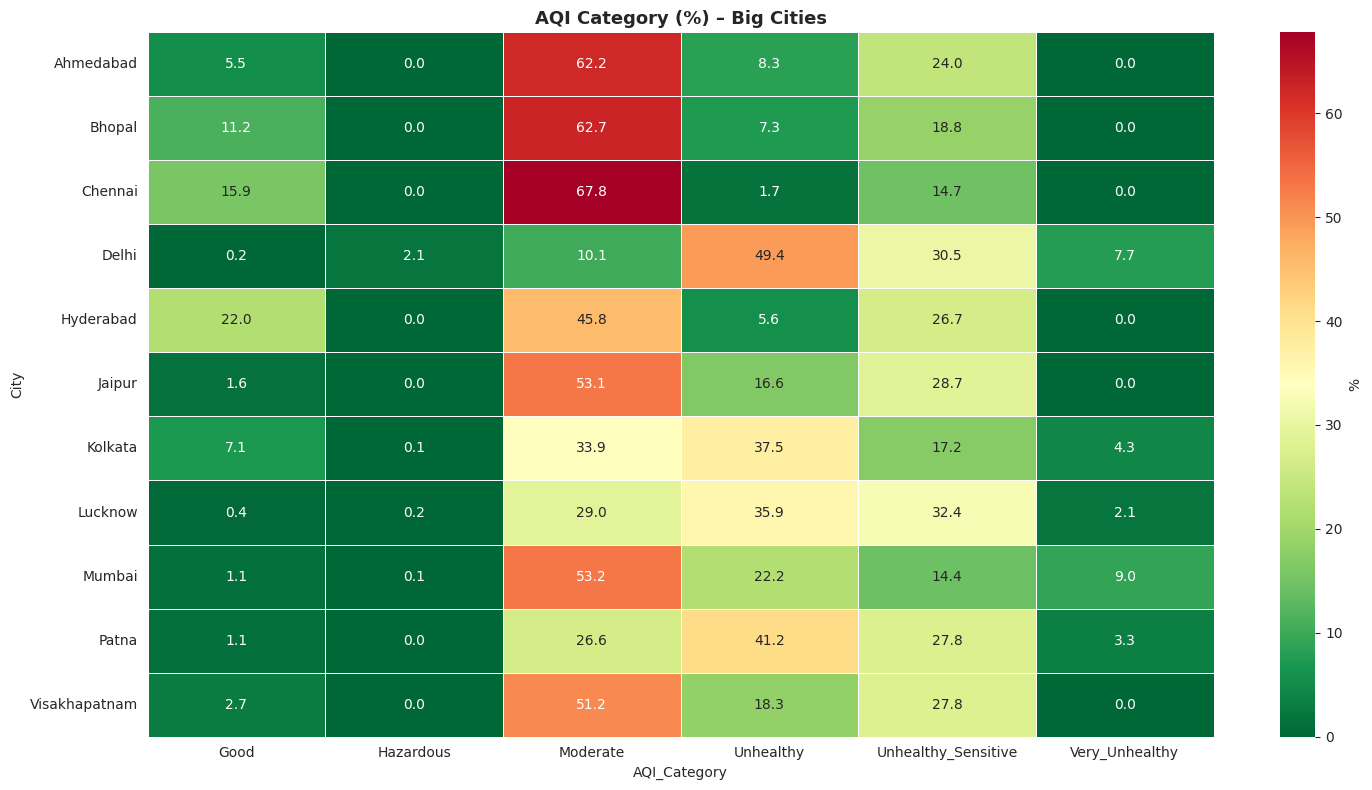

9160

In [ ]:
# Big cities AQI heatmap
BIG_CITIES = ['Delhi','Mumbai','Bangalore','Chennai','Kolkata',
               'Hyderabad','Pune','Ahmedabad','Jaipur','Lucknow',
               'Kanpur','Surat','Indore','Bhopal','Nagpur',
               'Visakhapatnam','Patna','Vadodara','Agra','Varanasi']
BIG_CITIES = [c for c in BIG_CITIES if c in df['City'].cat.categories]

df_big   = df[df['City'].isin(BIG_CITIES)]
city_aqi = df_big.groupby(['City','AQI_Category'], observed=True).size().unstack(fill_value=0)
city_pct = city_aqi.div(city_aqi.sum(axis=1), axis=0) * 100

plt.figure(figsize=(15, 8))
sns.heatmap(city_pct, annot=True, fmt='.1f', cmap='RdYlGn_r',
             linewidths=0.5, cbar_kws={'label': '%'})
plt.title('AQI Category (%) – Big Cities', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
del df_big; gc.collect()

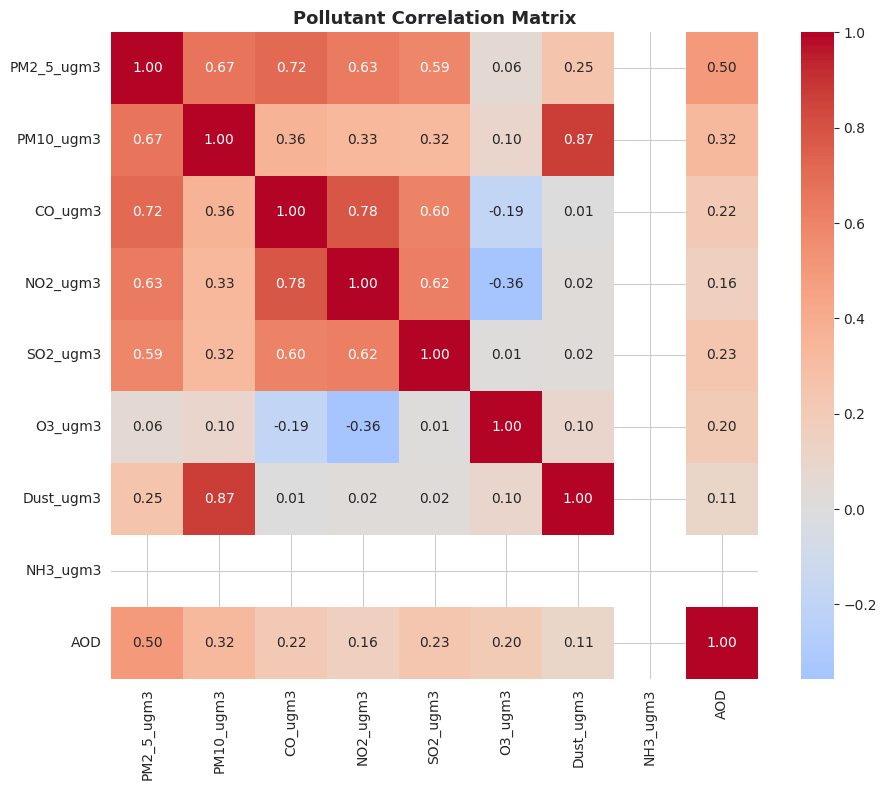

In [ ]:
# Pollutant correlation heatmap
pollutants = ['PM2_5_ugm3','PM10_ugm3','CO_ugm3','NO2_ugm3',
               'SO2_ugm3','O3_ugm3','Dust_ugm3','NH3_ugm3','AOD']
plt.figure(figsize=(10, 8))
sns.heatmap(df[pollutants].corr(), annot=True, fmt='.2f',
             cmap='coolwarm', center=0, square=True)
plt.title('Pollutant Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

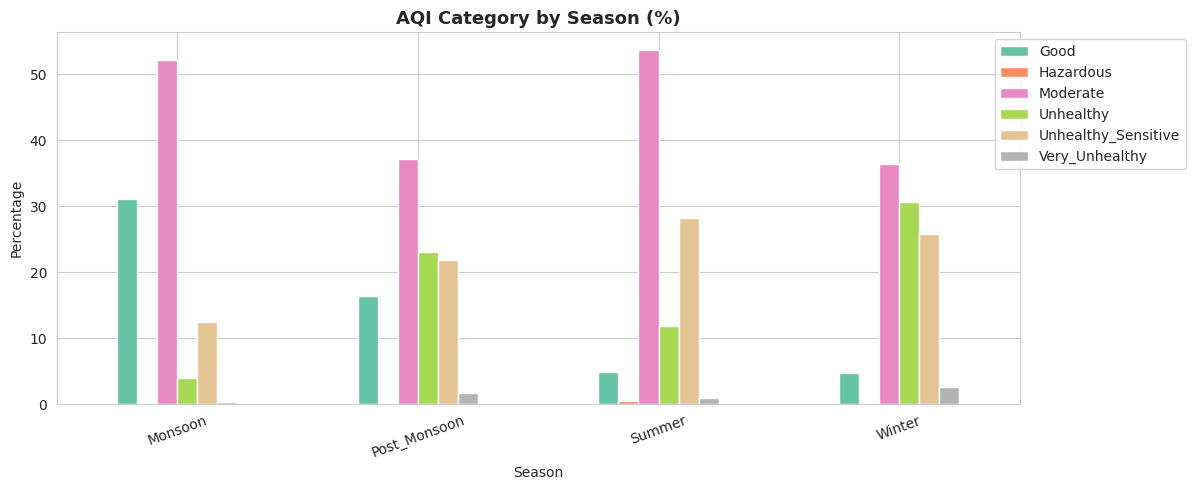

In [ ]:
# Seasonal AQI breakdown
season_aqi = df.groupby(['Season','AQI_Category'], observed=True).size().unstack(fill_value=0)
season_pct = season_aqi.div(season_aqi.sum(axis=1), axis=0) * 100
season_pct.plot(kind='bar', colormap='Set2', edgecolor='white', figsize=(12,5))
plt.title('AQI Category by Season (%)', fontsize=13, fontweight='bold')
plt.xticks(rotation=20); plt.ylabel('Percentage')
plt.legend(loc='upper right', bbox_to_anchor=(1.18,1))
plt.tight_layout(); plt.show()

## 🧹 4. Feature Engineering & Preprocessing

In [ ]:
df_ml = df.copy()
del df; gc.collect()  # free original df RAM

# ── Cyclical encoding for Hour and Month (circular nature)
df_ml['Hour_sin']  = np.sin(2*np.pi*df_ml['Hour'] /24).astype('float32')
df_ml['Hour_cos']  = np.cos(2*np.pi*df_ml['Hour'] /24).astype('float32')
df_ml['Month_sin'] = np.sin(2*np.pi*df_ml['Month']/12).astype('float32')
df_ml['Month_cos'] = np.cos(2*np.pi*df_ml['Month']/12).astype('float32')

# ── Drop Datetime (already have Year/Month/Day/Hour extracted)
df_ml.drop(columns=['Datetime'], inplace=True, errors='ignore')

# ── Drop LEAKAGE columns
# US_AQI, US_AQI_PM25/PM10/NO2/O3/CO → numeric AQI scores that DIRECTLY map to AQI_Category
# EU_AQI, EU_AQI_PM25/PM10           → same issue, direct leakage
# PM25_Category_India                → derived from PM2_5, mirrors target
LEAKAGE_COLS = [
    'US_AQI','US_AQI_PM25','US_AQI_PM10','US_AQI_NO2','US_AQI_O3','US_AQI_CO',
    'EU_AQI','EU_AQI_PM25','EU_AQI_PM10',
    'PM25_Category_India'
]
df_ml.drop(columns=LEAKAGE_COLS, inplace=True)
print(f'Dropped leakage columns: {LEAKAGE_COLS}')

# ── Handle nulls
for col in df_ml.select_dtypes(include=np.number).columns:
    if df_ml[col].isnull().any():
        df_ml[col] = df_ml.groupby('City')[col].transform(lambda x: x.fillna(x.median()))
        df_ml[col].fillna(df_ml[col].median(), inplace=True)
for col in df_ml.select_dtypes(include='category').columns:
    if df_ml[col].isnull().any():
        df_ml[col] = df_ml[col].fillna(df_ml[col].mode()[0])

# ── Encode categorical columns
TARGET   = 'AQI_Category'
ENCODE   = ['City','State','Day_Name','Season','Time_of_Day',
             'Humidity_Category','Wind_Category']
encoders = {}
for col in ENCODE:
    le = LabelEncoder() # Instantiate a new LabelEncoder for each column
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))
    encoders[col] = le

# Booleans → int8
for col in df_ml.select_dtypes(include='bool').columns:
    df_ml[col] = df_ml[col].astype('int8')

# Encode target
target_le     = LabelEncoder()
df_ml[TARGET] = target_le.fit_transform(df_ml[TARGET].astype(str))
CLASS_NAMES   = target_le.classes_

print(f'\nPreprocessing done. Shape: {df_ml.shape}')
print(f'Classes: {CLASS_NAMES}')
print(f'Memory: {df_ml.memory_usage(deep=True).sum()/1e6:.1f} MB')

Dropped leakage columns: ['US_AQI', 'US_AQI_PM25', 'US_AQI_PM10', 'US_AQI_NO2', 'US_AQI_O3', 'US_AQI_CO', 'EU_AQI', 'EU_AQI_PM25', 'EU_AQI_PM10', 'PM25_Category_India']

✅ Preprocessing done. Shape: (842160, 64)
Classes: ['Good' 'Hazardous' 'Moderate' 'Unhealthy' 'Unhealthy_Sensitive'
 'Very_Unhealthy']
Memory: 205.5 MB


## 5. Feature Selection (3-Step)
> Reduces features without compromising accuracy.

### Step 5.1 — Manual Drop (Redundant Features)

In [ ]:
MANUAL_DROP = {
    'Latitude'             : 'City already encodes location',
    'Longitude'            : 'City already encodes location',
    'Week_of_Year'         : 'Month + Season already covers seasonality',
    'Day_Name'             : 'Is_Weekend + Day_of_Week already covers this',
    'Day_of_Week'          : 'Is_Weekend is sufficient for weekday pattern',
    'Quarter'              : 'Month + Season already captures quarter info',
    'Temp_80m_C'           : 'Highly correlated with Temp_2m_C',
    'Temp_120m_C'          : 'Highly correlated with Temp_2m_C',
    'Temp_180m_C'          : 'Highly correlated with Temp_2m_C',
    'Wind_Speed_80m_kmh'   : 'Correlated with Wind_Speed_10m_kmh',
    'Wind_Speed_120m_kmh'  : 'Correlated with Wind_Speed_10m_kmh',
    'Rain_mm'              : 'Duplicate of Precipitation_mm',
    'Direct_Radiation_Wm2' : 'Correlated with Solar_Radiation_Wm2',
    'Diffuse_Radiation_Wm2': 'Correlated with Solar_Radiation_Wm2',
    'Cloud_Low_Percent'    : 'Captured by Cloud_Cover_Percent',
    'Cloud_Mid_Percent'    : 'Captured by Cloud_Cover_Percent',
    'Cloud_High_Percent'   : 'Captured by Cloud_Cover_Percent',
    'Sunshine_Seconds'     : 'Correlated with Is_Daytime + Solar_Radiation',
    'Surface_Pressure_hPa' : 'Highly correlated with Pressure_MSL_hPa',
}

print(f'=== Manually Dropping {len(MANUAL_DROP)} features ===')
for f, r in MANUAL_DROP.items():
    print(f'  {f:<25} → {r}')

df_s1 = df_ml.drop(columns=[c for c in MANUAL_DROP if c in df_ml.columns])
print(f'\nFeatures: {df_ml.shape[1]-1} → {df_s1.shape[1]-1}')

=== Manually Dropping 19 features ===
  ❌ Latitude                  → City already encodes location
  ❌ Longitude                 → City already encodes location
  ❌ Week_of_Year              → Month + Season already covers seasonality
  ❌ Day_Name                  → Is_Weekend + Day_of_Week already covers this
  ❌ Day_of_Week               → Is_Weekend is sufficient for weekday pattern
  ❌ Quarter                   → Month + Season already captures quarter info
  ❌ Temp_80m_C                → Highly correlated with Temp_2m_C
  ❌ Temp_120m_C               → Highly correlated with Temp_2m_C
  ❌ Temp_180m_C               → Highly correlated with Temp_2m_C
  ❌ Wind_Speed_80m_kmh        → Correlated with Wind_Speed_10m_kmh
  ❌ Wind_Speed_120m_kmh       → Correlated with Wind_Speed_10m_kmh
  ❌ Rain_mm                   → Duplicate of Precipitation_mm
  ❌ Direct_Radiation_Wm2      → Correlated with Solar_Radiation_Wm2
  ❌ Diffuse_Radiation_Wm2     → Correlated with Solar_Radiation_Wm2
  ❌ Cl

### Step 5.2 — Correlation Analysis

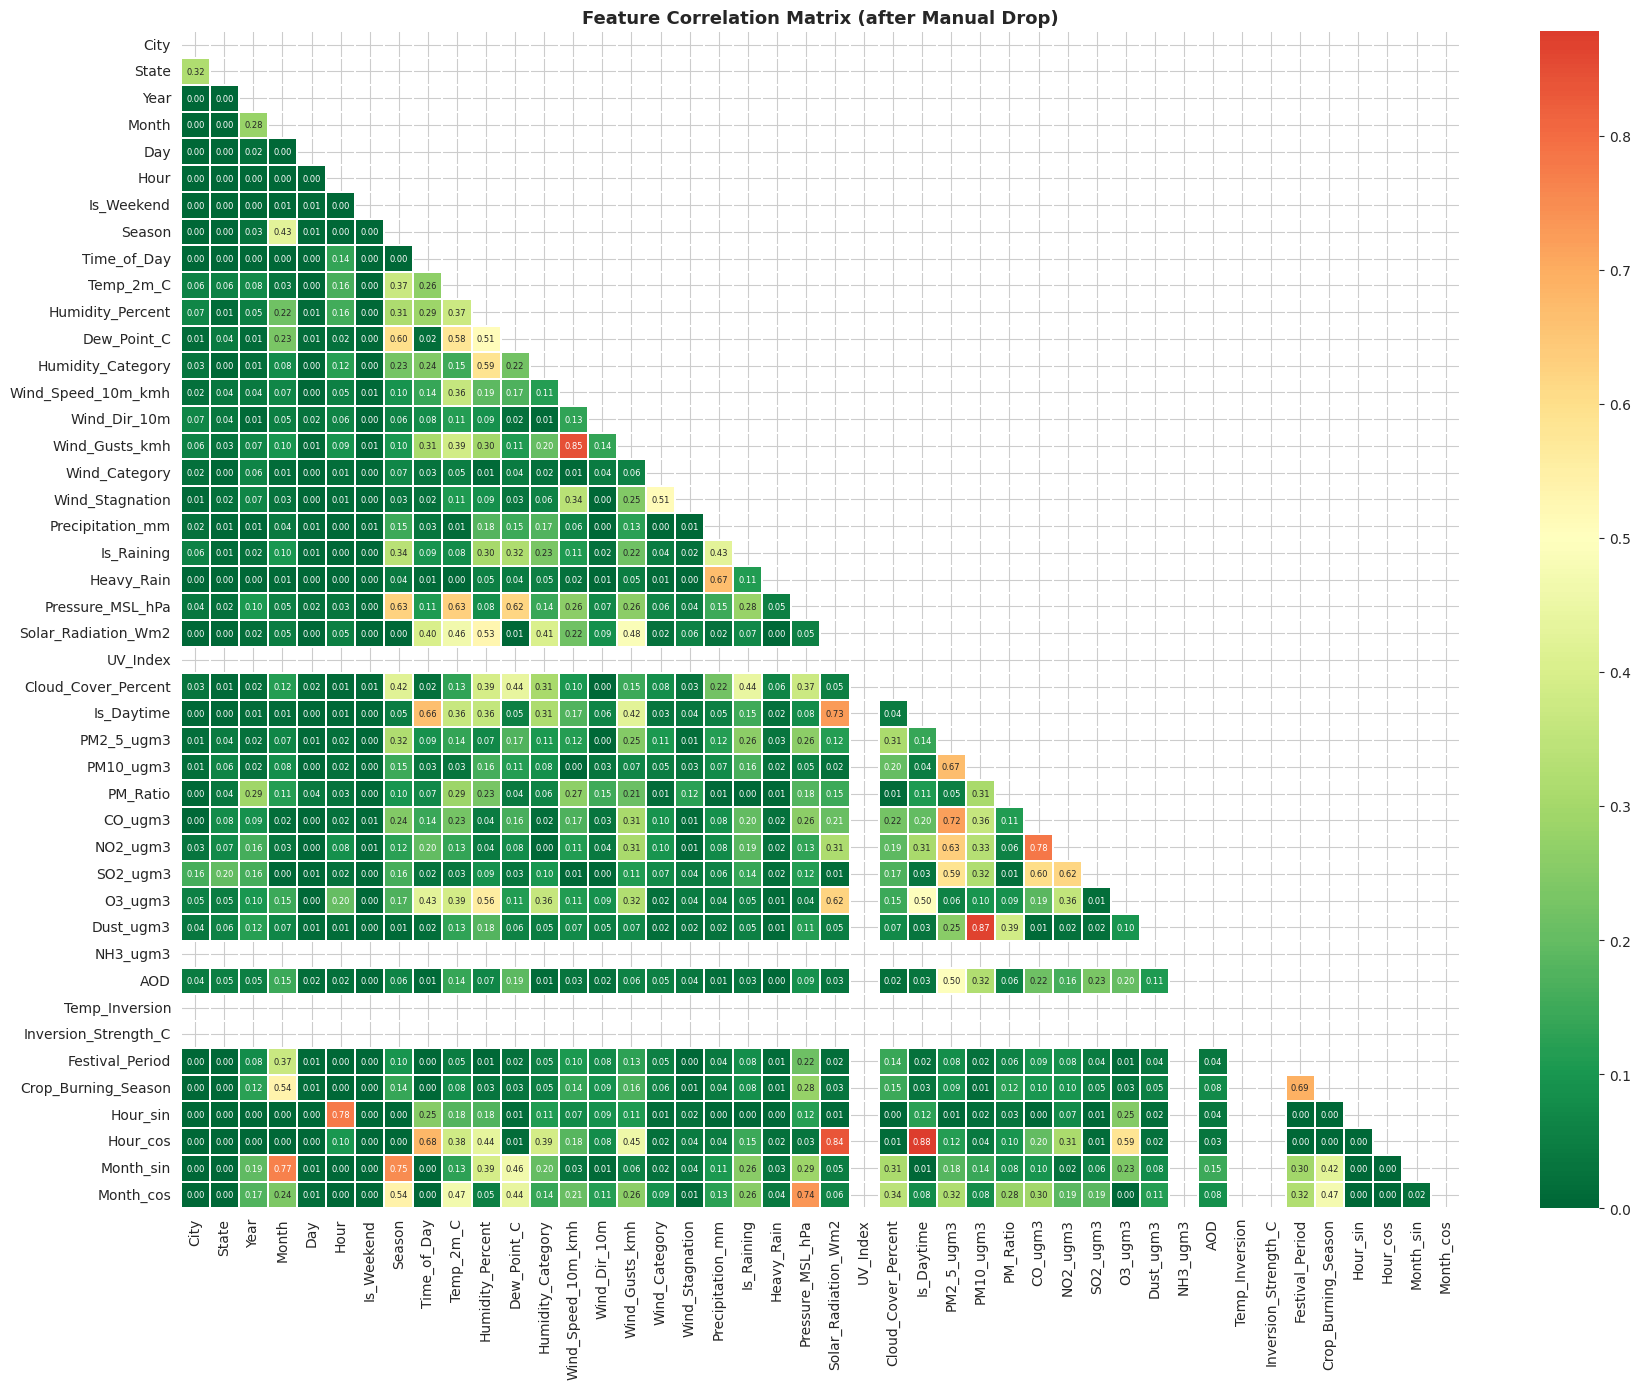

In [ ]:
num_feats   = df_s1.drop(columns=[TARGET]).select_dtypes(include=np.number).columns.tolist()
corr_matrix = df_s1[num_feats].corr().abs()

plt.figure(figsize=(18, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
             cmap='RdYlGn_r', center=0.5, linewidths=0.3,
             annot_kws={'size': 6})
plt.title('Feature Correlation Matrix (after Manual Drop)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

In [ ]:
CORR_THRESHOLD = 0.85
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = (
    upper.stack().reset_index()
    .rename(columns={'level_0':'A','level_1':'B',0:'Corr'})
    .query('Corr > @CORR_THRESHOLD')
    .sort_values('Corr', ascending=False)
)

to_drop_corr = set()
for _, row in high_corr.iterrows():
    a, b = row['A'], row['B']
    if a not in to_drop_corr and b not in to_drop_corr:
        drop = a if corr_matrix[a].mean() > corr_matrix[b].mean() else b
        to_drop_corr.add(drop)
        print(f'Drop: {drop:<30} (corr={row["Corr"]:.3f} with {a if drop==b else b})')

to_drop_corr = list(to_drop_corr)
df_s2 = df_s1.drop(columns=to_drop_corr)
print(f'\nFeatures: {df_s1.shape[1]-1} → {df_s2.shape[1]-1}  (dropped {len(to_drop_corr)})')
if not to_drop_corr:
    print('No pairs above threshold')

  ❌ Drop: Hour_cos                       (corr=0.878 with Is_Daytime)
  ❌ Drop: PM10_ugm3                      (corr=0.869 with Dust_ugm3)

Features: 44 → 42  (dropped 2)


### Step 5.3 — Feature Importance (LightGBM Quick Scan)

In [ ]:
# Train on 30% sample for speed — reliable enough to rank features
X_fi = df_s2.drop(columns=[TARGET])
y_fi = df_s2[TARGET]

Xs, _, ys, _ = train_test_split(X_fi, y_fi, train_size=0.30,
                                  stratify=y_fi, random_state=SEED)
Xtr, Xvl, ytr, yvl = train_test_split(Xs, ys, test_size=0.2,
                                        stratify=ys, random_state=SEED)

print(f'Quick scan on {len(Xtr):,} samples...')
fi_model = lgb.LGBMClassifier(
    n_estimators=300, max_depth=8, num_leaves=64,
    learning_rate=0.05, class_weight='balanced',
    n_jobs=-1, random_state=SEED, verbose=-1)
fi_model.fit(Xtr, ytr, eval_set=[(Xvl, yvl)],
              callbacks=[lgb.early_stopping(30, verbose=False),
                          lgb.log_evaluation(100)])

fi     = pd.Series(fi_model.feature_importances_, index=X_fi.columns)
fi_pct = (fi / fi.sum() * 100).sort_values(ascending=False).round(2)
fi_cum = fi_pct.cumsum()
del fi_model, Xs, Xtr, Xvl, ys, ytr, yvl; gc.collect()
print('Feature importance computed!')

Quick scan on 202,118 samples...
[100]	valid_0's multi_logloss: 0.577042
[200]	valid_0's multi_logloss: 0.517502
[300]	valid_0's multi_logloss: 0.487313
✅ Feature importance computed!


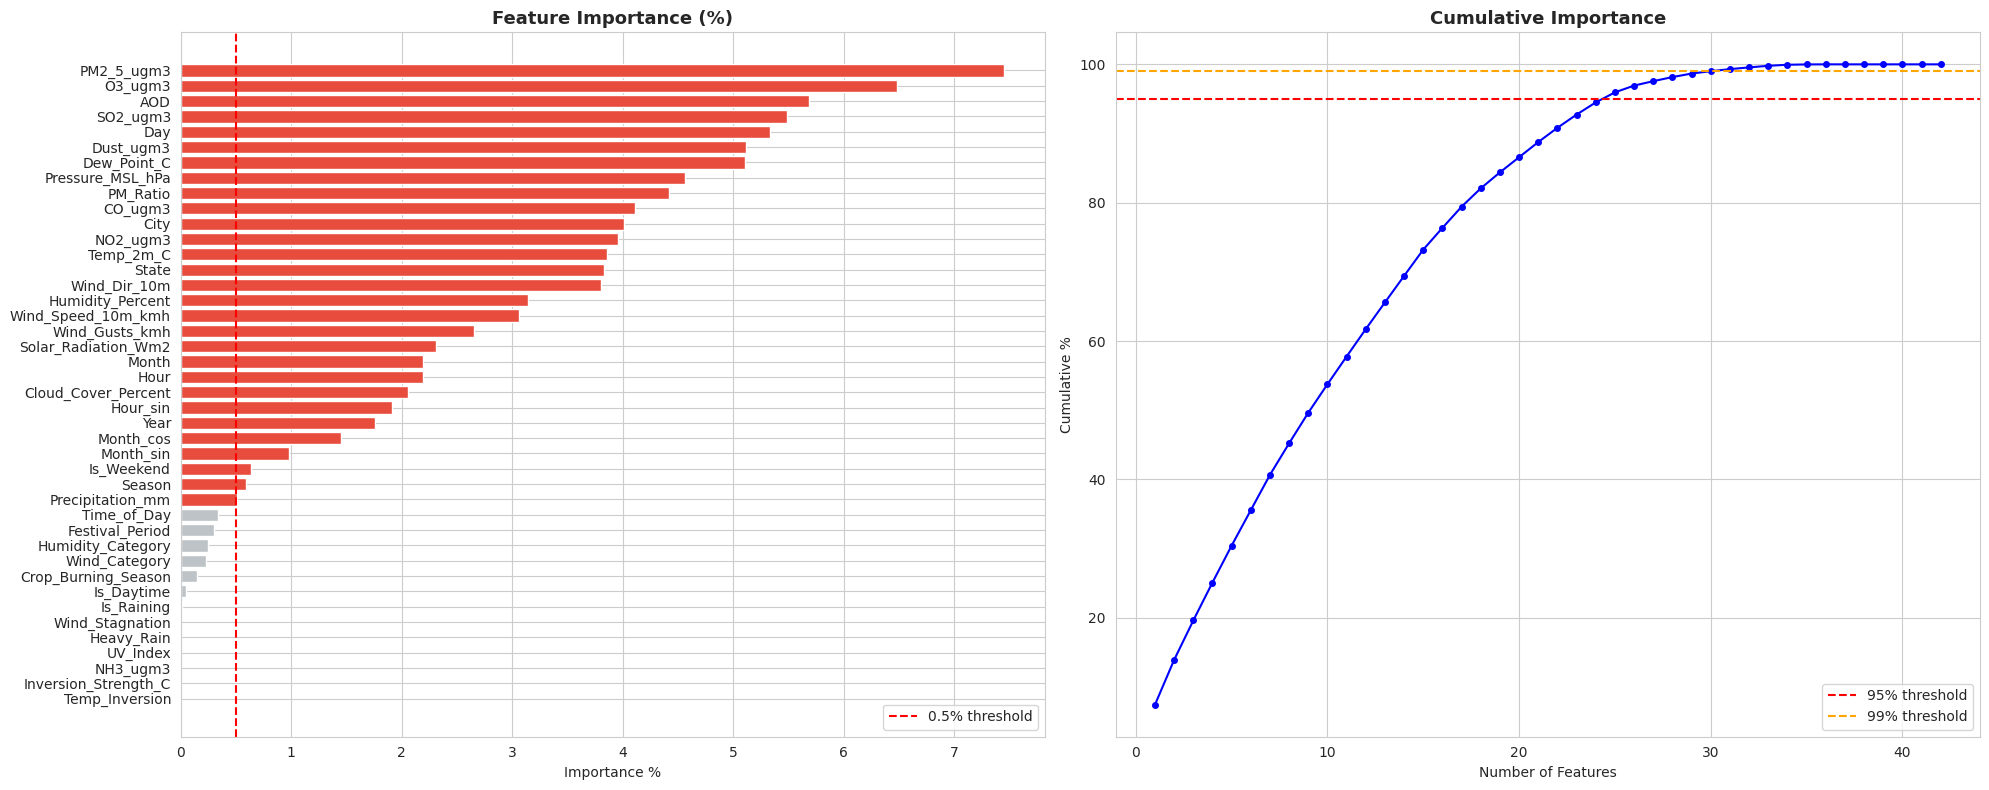


=== Full Feature Importance Table ===
                      Importance_%  Cumulative_%
PM2_5_ugm3                    7.45          7.45
O3_ugm3                       6.48         13.93
AOD                           5.69         19.62
SO2_ugm3                      5.49         25.11
Day                           5.33         30.44
Dust_ugm3                     5.12         35.56
Dew_Point_C                   5.11         40.67
Pressure_MSL_hPa              4.56         45.23
PM_Ratio                      4.42         49.65
CO_ugm3                       4.11         53.76
City                          4.01         57.77
NO2_ugm3                      3.96         61.73
Temp_2m_C                     3.86         65.59
State                         3.83         69.42
Wind_Dir_10m                  3.80         73.22
Humidity_Percent              3.14         76.36
Wind_Speed_10m_kmh            3.06         79.42
Wind_Gusts_kmh                2.65         82.07
Solar_Radiation_Wm2           

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

colors = ['#e74c3c' if v >= 0.5 else '#bdc3c7' for v in fi_pct.values]
axes[0].barh(fi_pct.index[::-1], fi_pct.values[::-1], color=colors[::-1])
axes[0].axvline(0.5, color='red', linestyle='--', label='0.5% threshold')
axes[0].set_title('Feature Importance (%)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Importance %'); axes[0].legend()

axes[1].plot(range(1, len(fi_cum)+1), fi_cum.values, 'b-o', markersize=4)
axes[1].axhline(95, color='red',    linestyle='--', label='95% threshold')
axes[1].axhline(99, color='orange', linestyle='--', label='99% threshold')
axes[1].set_title('Cumulative Importance', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Features'); axes[1].set_ylabel('Cumulative %')
axes[1].legend()
plt.tight_layout(); plt.show()

print('\n=== Full Feature Importance Table ===')
print(pd.DataFrame({'Importance_%': fi_pct, 'Cumulative_%': fi_cum}).to_string())

In [ ]:
IMPORTANCE_THRESHOLD = 0.5  # lower → keep more | higher → drop more

selected   = fi_pct[fi_pct >= IMPORTANCE_THRESHOLD].index.tolist()
dropped_fi = fi_pct[fi_pct <  IMPORTANCE_THRESHOLD].index.tolist()

print(f'=== Dropped by Importance (< {IMPORTANCE_THRESHOLD}%) ===')
for f in dropped_fi:
    print(f'  {f:<35} {fi_pct[f]:.2f}%')

df_final = df_s2[selected + [TARGET]]
print(f'\n Final feature count : {len(selected)}')
print(f'   Started with        : {df_ml.shape[1]-1}')
print(f'   Total dropped       : {(df_ml.shape[1]-1) - len(selected)}')
print(f'\nFinal features: {selected}')

=== Dropped by Importance (< 0.5%) ===
  ❌ Time_of_Day                         0.34%
  ❌ Festival_Period                     0.30%
  ❌ Humidity_Category                   0.25%
  ❌ Wind_Category                       0.23%
  ❌ Crop_Burning_Season                 0.15%
  ❌ Is_Daytime                          0.05%
  ❌ Is_Raining                          0.01%
  ❌ Wind_Stagnation                     0.00%
  ❌ Heavy_Rain                          0.00%
  ❌ UV_Index                            0.00%
  ❌ NH3_ugm3                            0.00%
  ❌ Inversion_Strength_C                0.00%
  ❌ Temp_Inversion                      0.00%

✅ Final feature count : 29
   Started with        : 63
   Total dropped       : 34

Final features: ['PM2_5_ugm3', 'O3_ugm3', 'AOD', 'SO2_ugm3', 'Day', 'Dust_ugm3', 'Dew_Point_C', 'Pressure_MSL_hPa', 'PM_Ratio', 'CO_ugm3', 'City', 'NO2_ugm3', 'Temp_2m_C', 'State', 'Wind_Dir_10m', 'Humidity_Percent', 'Wind_Speed_10m_kmh', 'Wind_Gusts_kmh', 'Solar_Radiation_Wm2'

## 6. Train / Val / Test Split

In [ ]:
X = df_final.drop(columns=[TARGET])
y = df_final[TARGET]
del df_ml, df_s1, df_s2, df_final; gc.collect()

# Stratified 70 / 15 / 15
X_tmp,  X_test, y_tmp,  y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp, test_size=0.176, stratify=y_tmp, random_state=SEED)
del X_tmp, y_tmp; gc.collect()

print(f'Train : {len(X_train):,} | Val : {len(X_val):,} | Test : {len(X_test):,}')

classes           = np.unique(y_train)
weights           = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes.tolist(), weights.tolist()))
print('\nClass weights:', {CLASS_NAMES[k]: round(v,3) for k,v in class_weight_dict.items()})

Train : 589,848 | Val : 125,988 | Test : 126,324

Class weights: {'Good': 1.029, 'Hazardous': 85.634, 'Moderate': 0.361, 'Unhealthy': 1.077, 'Unhealthy_Sensitive': 0.802, 'Very_Unhealthy': 13.556}


In [ ]:
# ── Check distribution BEFORE SMOTE
print('=== Class Distribution BEFORE SMOTE ===')
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    pct = c / len(y_train) * 100
    print(f'  {CLASS_NAMES[u]:<40} {c:>6,}  ({pct:.1f}%)')

# ── Apply SMOTE only on training data
# Val and test sets are NEVER touched — real data only
print('\nApplying SMOTE...')
sm = SMOTE(
    sampling_strategy='auto',  # balances all minority classes to match majority
    k_neighbors=5,
    random_state=SEED
)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# ── Check distribution AFTER SMOTE
print('\n=== Class Distribution AFTER SMOTE ===')
unique_r, counts_r = np.unique(y_train_res, return_counts=True)
for u, c in zip(unique_r, counts_r):
    pct = c / len(y_train_res) * 100
    print(f'  {CLASS_NAMES[u]:<40} {c:>6,}  ({pct:.1f}%)')

print(f'\nTraining samples: {len(y_train):,} → {len(y_train_res):,}')
gc.collect()

=== Class Distribution BEFORE SMOTE ===
  Good                                     95,576  (16.2%)
  Hazardous                                 1,148  (0.2%)
  Moderate                                 271,954  (46.1%)
  Unhealthy                                91,298  (15.5%)
  Unhealthy_Sensitive                      122,620  (20.8%)
  Very_Unhealthy                            7,252  (1.2%)

Applying SMOTE...

=== Class Distribution AFTER SMOTE ===
  Good                                     271,954  (16.7%)
  Hazardous                                271,954  (16.7%)
  Moderate                                 271,954  (16.7%)
  Unhealthy                                271,954  (16.7%)
  Unhealthy_Sensitive                      271,954  (16.7%)
  Very_Unhealthy                           271,954  (16.7%)

Training samples: 589,848 → 1,631,724


0

## 7. Model Training

### 7.1 LightGBM

In [ ]:
print('Training LightGBM...')
lgb_clf = lgb.LGBMClassifier(
    n_estimators=500, max_depth=10, num_leaves=64,
    learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    class_weight='balanced', n_jobs=-1,
    random_state=SEED, verbose=-1
)
lgb_clf.fit(
    X_train_res, y_train_res,   # ← changed
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=True),
               lgb.log_evaluation(100)]
)
lgb_preds = lgb_clf.predict(X_val)
lgb_acc   = accuracy_score(y_val, lgb_preds)
lgb_f1    = f1_score(y_val, lgb_preds, average='weighted')
print(f'\n✅ LightGBM  →  Val Acc: {lgb_acc:.4f}  |  Val F1: {lgb_f1:.4f}')

Training LightGBM...
Training until validation scores don't improve for 50 rounds
[100]	valid_0's multi_logloss: 0.532316
[200]	valid_0's multi_logloss: 0.471853
[300]	valid_0's multi_logloss: 0.442348
[400]	valid_0's multi_logloss: 0.421732
[500]	valid_0's multi_logloss: 0.406677
Did not meet early stopping. Best iteration is:
[500]	valid_0's multi_logloss: 0.406677

✅ LightGBM  →  Val Acc: 0.8297  |  Val F1: 0.8299


### 7.2 XGBoost

In [ ]:
print('Training XGBoost...')
sample_weights = np.array([class_weight_dict[c] for c in y_train_res])
xgb_clf = xgb.XGBClassifier(
    n_estimators=500, max_depth=8, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    eval_metric='mlogloss', tree_method='hist',
    n_jobs=-1, random_state=SEED, verbosity=1
)
xgb_clf.fit(
    X_train_res, y_train_res,
    sample_weight=sample_weights,
    eval_set=[(X_val, y_val)],
    verbose=100
)
xgb_preds = xgb_clf.predict(X_val)
xgb_acc   = accuracy_score(y_val, xgb_preds)
xgb_f1    = f1_score(y_val, xgb_preds, average='weighted')
print(f'\n✅ XGBoost  →  Val Acc: {xgb_acc:.4f}  |  Val F1: {xgb_f1:.4f}')

Training XGBoost...
[0]	validation_0-mlogloss:3.22699
[100]	validation_0-mlogloss:0.81291
[200]	validation_0-mlogloss:0.65430
[300]	validation_0-mlogloss:0.58440
[400]	validation_0-mlogloss:0.54117
[499]	validation_0-mlogloss:0.51016

✅ XGBoost  →  Val Acc: 0.7832  |  Val F1: 0.7869


### 7.3 Random Forest

In [ ]:
print('Training Random Forest...')
rf = RandomForestClassifier(
    n_estimators=200, max_depth=18,
    min_samples_leaf=5, max_features='sqrt',
    class_weight='balanced', n_jobs=-1,
    random_state=SEED, verbose=1
)
rf.fit(X_train_res, y_train_res)
rf_preds = rf.predict(X_val)
rf_acc   = accuracy_score(y_val, rf_preds)
rf_f1    = f1_score(y_val, rf_preds, average='weighted')
print(f'\n✅ Random Forest  →  Val Acc: {rf_acc:.4f}  |  Val F1: {rf_f1:.4f}')

Training Random Forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:  6.9min
[Parallel(n_jobs=-1)]: Done 196 tasks      | elapsed: 30.8min
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed: 31.3min finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    1.1s



✅ Random Forest  →  Val Acc: 0.8156  |  Val F1: 0.8188


[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    4.4s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    4.5s finished


## 8. Model Comparison

=== Validation Leaderboard ===
        Model  Features  Val Acc   Val F1
     LightGBM        29 0.829722 0.829897
Random Forest        29 0.815649 0.818753
      XGBoost        29 0.783241 0.786939


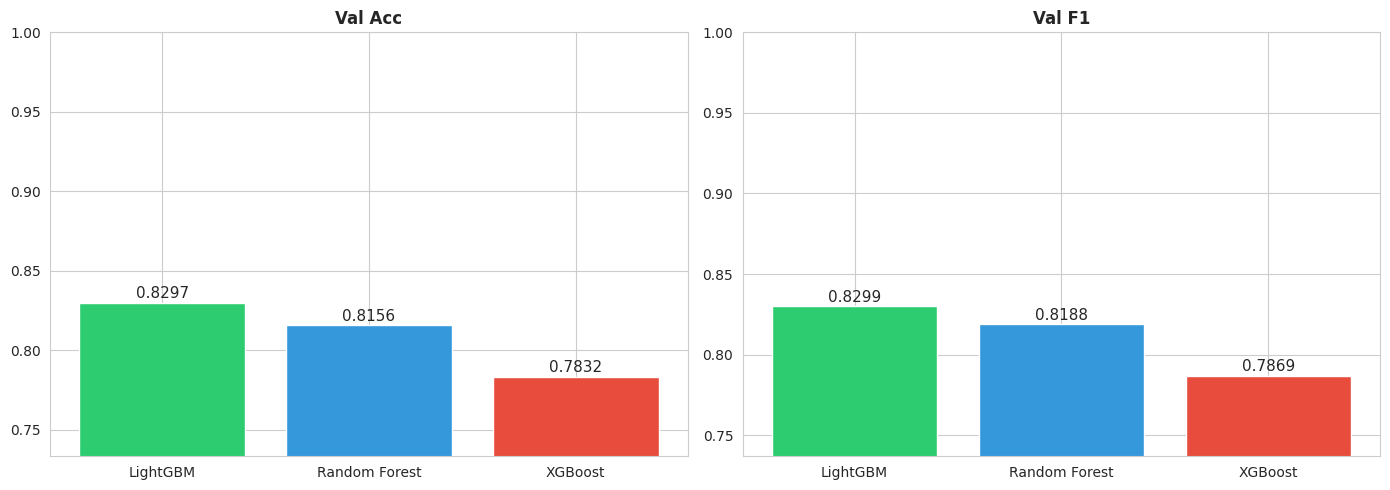

In [ ]:
results = pd.DataFrame({
    'Model':    ['LightGBM','XGBoost','Random Forest'],
    'Features': [X_train.shape[1]]*3,
    'Val Acc':  [lgb_acc, xgb_acc, rf_acc],
    'Val F1':   [lgb_f1,  xgb_f1,  rf_f1],
}).sort_values('Val F1', ascending=False).reset_index(drop=True)

print('=== Validation Leaderboard ===')
print(results.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
clrs = ['#2ecc71','#3498db','#e74c3c']
for ax, metric in zip(axes, ['Val Acc','Val F1']):
    bars = ax.bar(results['Model'], results[metric], color=clrs, edgecolor='white')
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylim(max(0, results[metric].min()-0.05), 1.0)
    for bar, val in zip(bars, results[metric]):
        ax.text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.003,
                 f'{val:.4f}', ha='center', fontsize=11)
plt.tight_layout(); plt.show()

## 9. Best Model — Final Test Evaluation

In [ ]:
best_name  = results.iloc[0]['Model']
model_map  = {'LightGBM': lgb_clf, 'XGBoost': xgb_clf, 'Random Forest': rf}
best_model = model_map[best_name]
print(f'Best model: {best_name}')

y_pred   = best_model.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
test_f1  = f1_score(y_test, y_pred, average='weighted')
print(f'\n=== FINAL TEST RESULTS ===')
print(f'Accuracy : {test_acc:.4f}')
print(f'F1 Score : {test_f1:.4f}')

Best model: LightGBM

=== FINAL TEST RESULTS ===
Accuracy : 0.8297
F1 Score : 0.8299


##  10. Classification Report & Confusion Matrix

In [ ]:
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

                     precision    recall  f1-score   support

               Good       0.86      0.86      0.86     20469
          Hazardous       0.54      0.87      0.67       246
           Moderate       0.87      0.87      0.87     58243
          Unhealthy       0.85      0.81      0.83     19553
Unhealthy_Sensitive       0.73      0.72      0.72     26260
     Very_Unhealthy       0.62      0.78      0.69      1553

           accuracy                           0.83    126324
          macro avg       0.75      0.82      0.78    126324
       weighted avg       0.83      0.83      0.83    126324



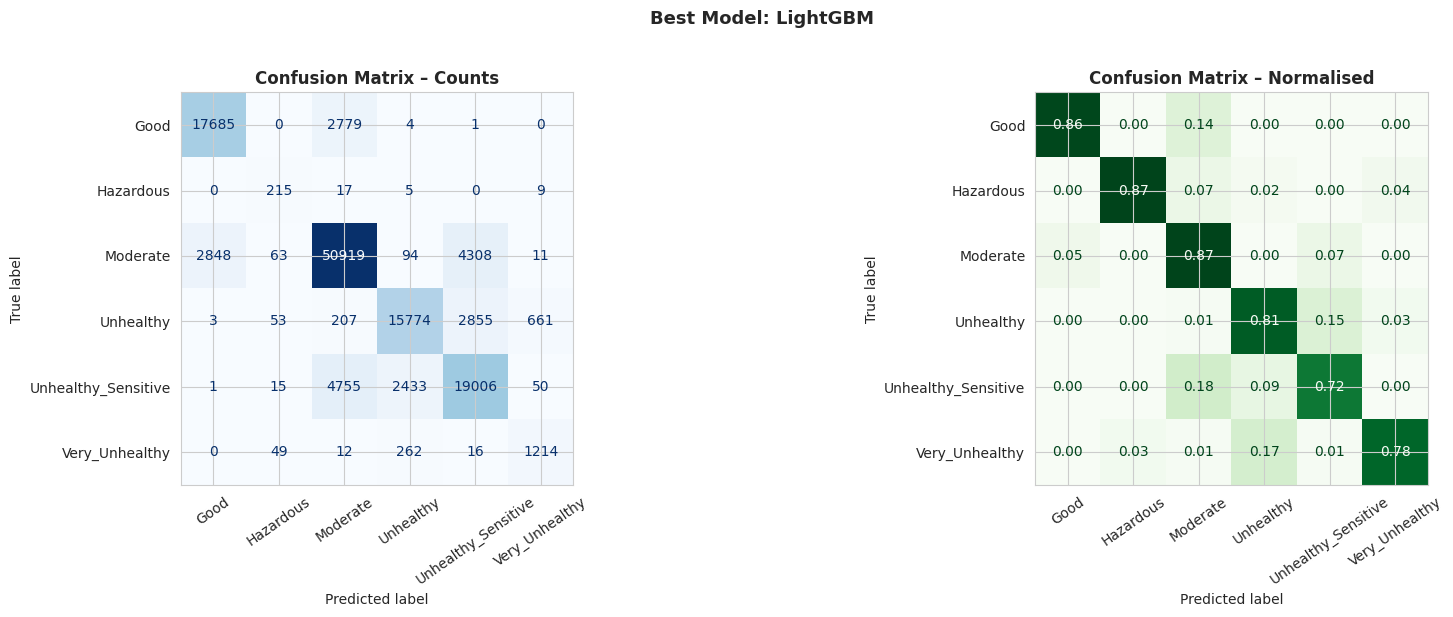

In [ ]:
cm = confusion_matrix(y_test, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix – Counts', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=35)

cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(cm_norm, display_labels=CLASS_NAMES).plot(
    ax=axes[1], colorbar=False, cmap='Greens', values_format='.2f')
axes[1].set_title('Confusion Matrix – Normalised', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=35)

plt.suptitle(f'Best Model: {best_name}', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

## 11. Feature Importance

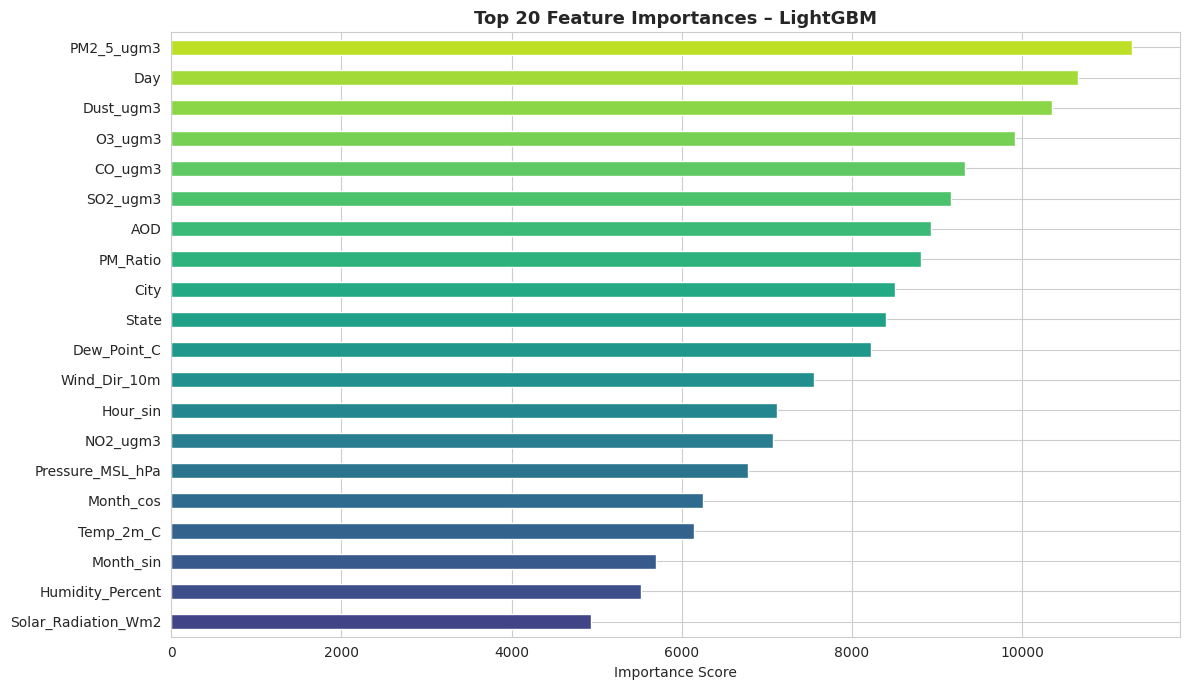

PM2_5_ugm3    11291
Day           10661
Dust_ugm3     10347
O3_ugm3        9915
CO_ugm3        9332
SO2_ugm3       9170
AOD            8933
PM_Ratio       8809
City           8508
State          8395


In [ ]:
fi_final  = pd.Series(best_model.feature_importances_, index=X.columns)
fi_sorted = fi_final.sort_values(ascending=False).head(20)

fi_sorted.plot(kind='barh',
               color=plt.cm.viridis(np.linspace(0.2, 0.9, len(fi_sorted)))[::-1],
               figsize=(12, 7))
plt.title(f'Top 20 Feature Importances – {best_name}', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()
print(fi_sorted.head(10).to_string())

## 12. Per-City Accuracy (Big Cities)

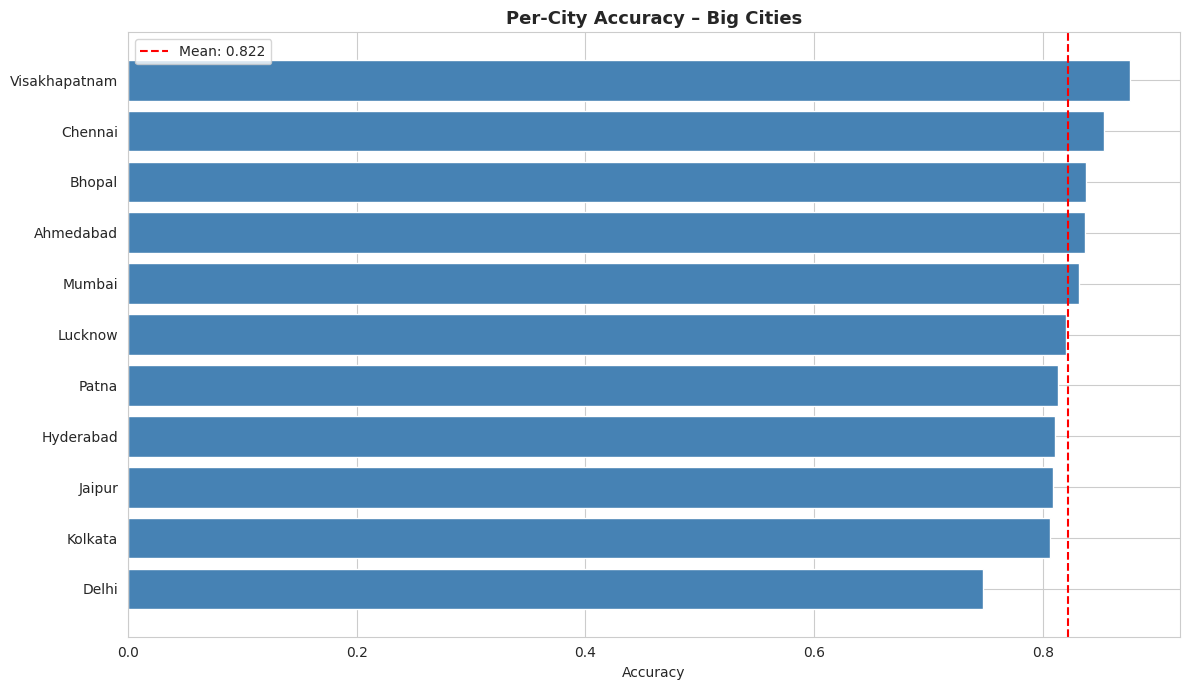

9131

In [ ]:
X_tc              = X_test.copy()
X_tc['True']      = y_test.values
X_tc['Predicted'] = y_pred
X_tc['City_Name'] = encoders['City'].inverse_transform(X_tc['City'].astype(int))

city_acc = (
    X_tc.groupby('City_Name')
    .apply(lambda g: accuracy_score(g['True'], g['Predicted']))
    .reset_index()
)
city_acc.columns = ['City','Accuracy']
city_acc_big = city_acc[city_acc['City'].isin(BIG_CITIES)].sort_values('Accuracy')

plt.figure(figsize=(12, 7))
plt.barh(city_acc_big['City'], city_acc_big['Accuracy'],
          color='steelblue', edgecolor='white')
mean_acc = city_acc_big['Accuracy'].mean()
plt.axvline(mean_acc, color='red', linestyle='--', label=f'Mean: {mean_acc:.3f}')
plt.title('Per-City Accuracy – Big Cities', fontsize=13, fontweight='bold')
plt.xlabel('Accuracy'); plt.legend()
plt.tight_layout(); plt.show()
del X_tc; gc.collect()

## 13. Save & Download Model

In [ ]:
from google.colab import files

save_name = best_name.replace(' ','_')
joblib.dump(best_model,      f'best_model_{save_name}.pkl')
joblib.dump(target_le,        'target_label_encoder.pkl')
joblib.dump(encoders,         'feature_encoders.pkl')
joblib.dump(list(X.columns),  'feature_columns.pkl')

for fname in [f'best_model_{save_name}.pkl','target_label_encoder.pkl',
               'feature_encoders.pkl','feature_columns.pkl']:
    files.download(fname)
    print(f'Downloaded: {fname}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: best_model_LightGBM.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: feature_encoders.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: feature_columns.pkl


## 14. Inference — Predict on New Data

In [ ]:
# ── Fill in any hourly reading to get an AQI prediction ───────────────────
sample = pd.DataFrame([{
    'City': 'Delhi',         'State': 'Delhi',
    'Latitude': 28.6139,     'Longitude': 77.2090,
    'Year': 2024,            'Month': 11,
    'Day': 15,               'Hour': 8,
    'Day_of_Week': 0,        'Day_Name': 'Monday',
    'Week_of_Year': 46,      'Is_Weekend': False,
    'Quarter': 4,            'Season': 'Winter',
    'Time_of_Day': 'Morning',
    'Temp_2m_C': 18.0,       'Temp_80m_C': 20.0,
    'Temp_120m_C': 21.0,     'Temp_180m_C': 22.0,
    'Humidity_Percent': 65.0,'Dew_Point_C': 10.0,
    'Humidity_Category': 'Comfortable',
    'Wind_Speed_10m_kmh': 10.0, 'Wind_Speed_80m_kmh': 12.0,
    'Wind_Speed_120m_kmh': 13.0,'Wind_Dir_10m': 180.0,
    'Wind_Gusts_kmh': 15.0,  'Wind_Category': 'Light',
    'Wind_Stagnation': False,
    'Precipitation_mm': 0.0, 'Rain_mm': 0.0,
    'Is_Raining': False,     'Heavy_Rain': False,
    'Pressure_MSL_hPa': 1015.0, 'Surface_Pressure_hPa': 1013.0,
    'Solar_Radiation_Wm2': 200.0, 'Direct_Radiation_Wm2': 150.0,
    'Diffuse_Radiation_Wm2': 50.0, 'UV_Index': 3.0,
    'Cloud_Cover_Percent': 20.0, 'Cloud_Low_Percent': 5.0,
    'Cloud_Mid_Percent': 10.0,   'Cloud_High_Percent': 5.0,
    'Is_Daytime': True,      'Sunshine_Seconds': 3600.0,
    'PM2_5_ugm3': 120.0,     'PM10_ugm3': 200.0,
    'PM_Ratio': 0.6,         'CO_ugm3': 800.0,
    'NO2_ugm3': 45.0,        'SO2_ugm3': 15.0,
    'O3_ugm3': 40.0,         'Dust_ugm3': 10.0,
    'NH3_ugm3': 5.0,         'AOD': 0.8,
    'Temp_Inversion': True,  'Inversion_Strength_C': 2.5,
    'Festival_Period': False,'Crop_Burning_Season': True,
}])

# Add cyclical features
sample['Hour_sin']  = np.sin(2*np.pi*sample['Hour'] /24)
sample['Hour_cos']  = np.cos(2*np.pi*sample['Hour'] /24)
sample['Month_sin'] = np.sin(2*np.pi*sample['Month']/12)
sample['Month_cos'] = np.cos(2*np.pi*sample['Month']/12)

# Encode categoricals
for col in ['City','State','Day_Name','Season','Time_of_Day',
             'Humidity_Category','Wind_Category']:
    if col in encoders:
        # Debugging step: print learned classes for the current encoder
        print(f"DEBUG: Encoder for '{col}' learned classes: {encoders[col].classes_}")
        sample[col] = encoders[col].transform(sample[col].astype(str))

# Booleans → int
for col in ['Is_Weekend','Wind_Stagnation','Is_Raining','Heavy_Rain',
             'Is_Daytime','Temp_Inversion','Festival_Period','Crop_Burning_Season']:
    sample[col] = sample[col].astype(int)

# Keep only selected features in correct order
feat_cols = joblib.load('feature_columns.pkl')
sample    = sample[[c for c in feat_cols if c in sample.columns]]

pred_label = target_le.inverse_transform(best_model.predict(sample))[0]
pred_proba = best_model.predict_proba(sample)[0]

print(f'🌫️  Predicted AQI Category: {pred_label}')
print('\nClass probabilities:')
for cls, prob in sorted(zip(CLASS_NAMES, pred_proba), key=lambda x: -x[1]):
    bar = '█' * int(prob * 40)
    print(f'  {cls:<40} {bar} {prob:.3f}')

DEBUG: Encoder for 'City' learned classes: ['Agartala' 'Ahmedabad' 'Aizawl' 'Bengaluru' 'Bhopal' 'Bhubaneswar'
 'Chandigarh' 'Chennai' 'Dehradun' 'Delhi' 'Gangtok' 'Gurugram' 'Guwahati'
 'Hyderabad' 'Imphal' 'Itanagar' 'Jaipur' 'Kohima' 'Kolkata' 'Lucknow'
 'Mumbai' 'Panaji' 'Patna' 'Raipur' 'Ranchi' 'Shillong' 'Shimla'
 'Thiruvananthapuram' 'Visakhapatnam']
DEBUG: Encoder for 'State' learned classes: ['Andhra Pradesh' 'Arunachal Pradesh' 'Assam' 'Bihar' 'Chhattisgarh'
 'Delhi' 'Goa' 'Gujarat' 'Haryana' 'Himachal Pradesh' 'Jharkhand'
 'Karnataka' 'Kerala' 'Madhya Pradesh' 'Maharashtra' 'Manipur' 'Meghalaya'
 'Mizoram' 'Nagaland' 'Odisha' 'Punjab' 'Rajasthan' 'Sikkim' 'Tamil Nadu'
 'Telangana' 'Tripura' 'Uttar Pradesh' 'Uttarakhand' 'West Bengal']
DEBUG: Encoder for 'Day_Name' learned classes: ['Friday' 'Monday' 'Saturday' 'Sunday' 'Thursday' 'Tuesday' 'Wednesday']
DEBUG: Encoder for 'Season' learned classes: ['Monsoon' 'Post_Monsoon' 'Summer' 'Winter']
DEBUG: Encoder for 'Time_of_Day' 